In [1]:
import pandas as pd
import dgl
import torch
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path


DATA_FOLDER = '/mnt/d/TON_IoT_Dataset'

/mnt/c/Users/User/Desktop/iot-ids-gnn/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# df_list = []
# for filename in os.listdir(DATA_FOLDER):
#     file_path = os.path.join(DATA_FOLDER, filename)
#     if os.path.isfile(file_path):
#         df = pd.read_csv(file_path)
#         df_list.append(df)

# combined_df = pd.concat(df_list, ignore_index=True)

# combined_df.head()

# combined_df.to_csv(Path(DATA_FOLDER) / 'combined.csv', index=False)

In [2]:
df = pd.read_csv(Path(DATA_FOLDER) / 'combined.csv', low_memory=False)
df

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type,uid
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852,41933215,...,0,-,-,-,bad_TCP_checksum,-,F,0,normal,NaN
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0,0,...,0,-,-,-,-,-,-,0,normal,NaN
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,0,-,-,-,bad_TCP_checksum,-,F,0,normal,NaN
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0,-,-,-,-,-,-,0,normal,NaN
4,1554198362,192.168.1.152,46608,192.168.1.190,53,udp,dns,0.000549,0,298,...,0,-,-,-,bad_UDP_checksum,-,F,0,normal,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22339016,1556145104,192.168.1.30,3050,192.168.1.194,3050,tcp,-,0.000011,0,0,...,0,-,-,-,-,-,-,1,dos,NaN
22339017,1556145104,192.168.1.30,3050,192.168.1.184,3050,tcp,-,0.000016,0,0,...,0,-,-,-,-,-,-,1,dos,NaN
22339018,1556145104,192.168.1.30,3050,192.168.1.184,3050,tcp,-,0.000113,0,0,...,0,-,-,-,-,-,-,1,dos,NaN
22339019,1556145104,192.168.1.30,3050,192.168.1.194,3050,tcp,-,0.000088,0,0,...,0,-,-,-,-,-,-,1,dos,NaN


In [3]:
split_secs = 20
start_time = df['ts'].min()
df['time_group'] = (df['ts'] - start_time) // split_secs
df.to_csv(Path(DATA_FOLDER) / 'combined.csv', index=False)
df

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type,uid,time_group
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852,41933215,...,-,-,-,bad_TCP_checksum,-,F,0,normal,NaN,0
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0,0,...,-,-,-,-,-,-,0,normal,NaN,0
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,-,-,-,bad_TCP_checksum,-,F,0,normal,NaN,0
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,-,-,-,-,-,-,0,normal,NaN,0
4,1554198362,192.168.1.152,46608,192.168.1.190,53,udp,dns,0.000549,0,298,...,-,-,-,bad_UDP_checksum,-,F,0,normal,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22339016,1556145104,192.168.1.30,3050,192.168.1.194,3050,tcp,-,0.000011,0,0,...,-,-,-,-,-,-,1,dos,NaN,97337
22339017,1556145104,192.168.1.30,3050,192.168.1.184,3050,tcp,-,0.000016,0,0,...,-,-,-,-,-,-,1,dos,NaN,97337
22339018,1556145104,192.168.1.30,3050,192.168.1.184,3050,tcp,-,0.000113,0,0,...,-,-,-,-,-,-,1,dos,NaN,97337
22339019,1556145104,192.168.1.30,3050,192.168.1.194,3050,tcp,-,0.000088,0,0,...,-,-,-,-,-,-,1,dos,NaN,97337


In [5]:
# Group by time_group and apply the labeling rules
def label_group(group):
    unique_labels = set(group['type'].unique())
    if len(unique_labels) == 1:
        return unique_labels.pop()
    elif 'normal' in unique_labels and len(unique_labels) == 2:
        unique_labels.remove('normal')
        return unique_labels.pop()
    else:
        return 'Unknown'

# Create the new labeling DataFrame
label_df = df.groupby('time_group').apply(label_group).reset_index()
label_df.columns = ['time_group', 'label']

def split_train_test(group):
    n = len(group)
    train_end = int(n * 0.8)
    group['type'] = ['train'] * train_end + ['test'] * (n - train_end)
    return group

labeled_with_split = label_df.groupby('label', group_keys=False).apply(split_train_test)

# Save the result
output_path = "combined-labels.csv"
labeled_with_split.to_csv(output_path, index=False)
print(f"Saved to {output_path}")


Saved to combined-labels.csv


/tmp/ipykernel_16901/3359704590.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  label_df = df.groupby('time_group').apply(label_group).reset_index()
/tmp/ipykernel_16901/3359704590.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  labeled_with_split = label_df.groupby('label', group_keys=False).apply(split_train_test)


In [ ]:
label_df = pd.read_csv(Path(DATA_FOLDER) / 'combined-labels.csv')
label_df['label'].value_counts()

# TODO: label train / test data

label
normal        8889
backdoor      4664
ddos          3010
password      2521
dos           1551
xss           1250
injection      738
scanning       707
ransomware     225
mitm           170
Name: count, dtype: int64

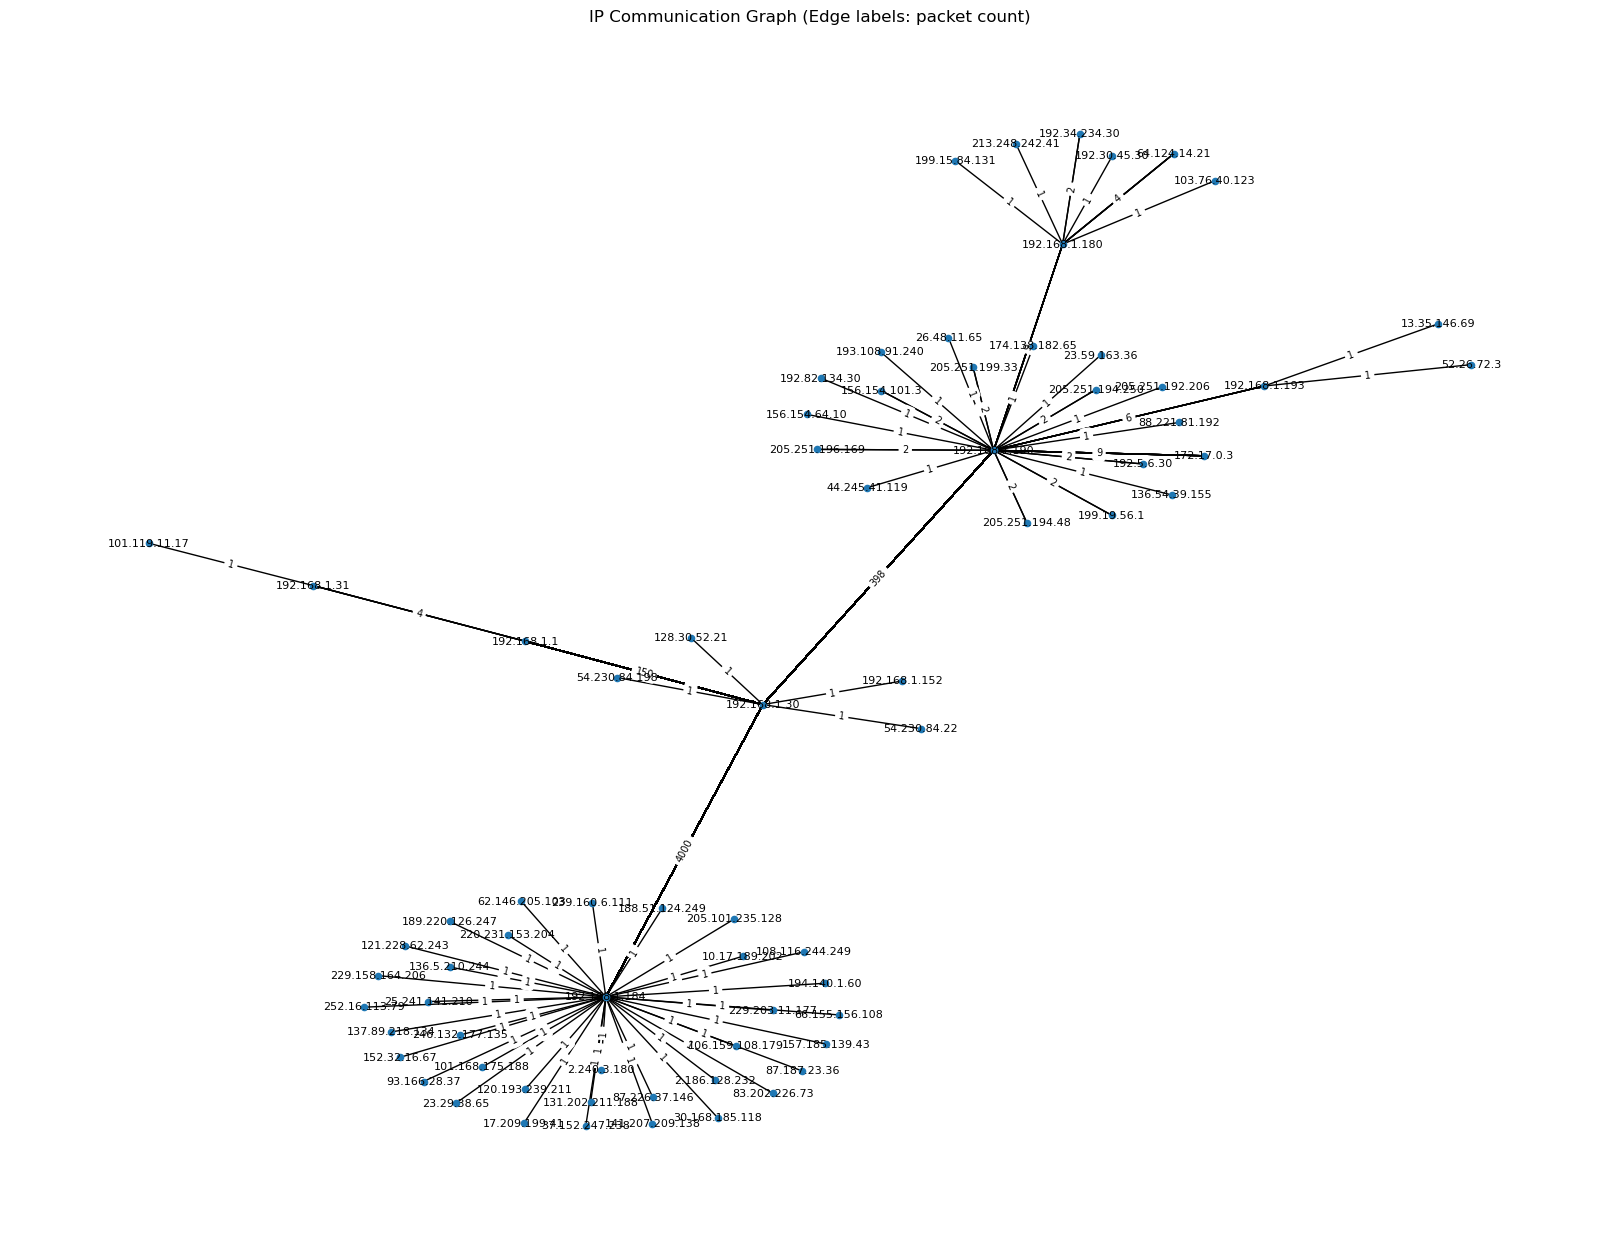

In [4]:
combined_df = df[df['time_group'] == 100270].copy()  # Filter for a specific time interval

# Extract unique IP addresses and map to node indices
ips = pd.unique(combined_df[['src_ip', 'dst_ip']].values.ravel())
ip_to_idx = {ip: idx for idx, ip in enumerate(ips)}
idx_to_ip = {idx: ip for ip, idx in ip_to_idx.items()}
labels = {idx: ip for idx, ip in idx_to_ip.items()}

# Create edge lists
src_indices = combined_df['src_ip'].map(ip_to_idx).values
dst_indices = combined_df['dst_ip'].map(ip_to_idx).values

edge_counts = (
    combined_df.groupby(['src_ip', 'dst_ip'])
    .size()
    .reset_index(name='count')
)

# Map IPs to indices for edge labeling
edge_counts['src_idx'] = edge_counts['src_ip'].map(ip_to_idx)
edge_counts['dst_idx'] = edge_counts['dst_ip'].map(ip_to_idx)

# Create a dictionary for edge labels: {(src_idx, dst_idx): count}
edge_labels = {
    (row['src_idx'], row['dst_idx']): row['count']
    for _, row in edge_counts.iterrows()
}

# Create DGL graph
g = dgl.graph((torch.tensor(src_indices), torch.tensor(dst_indices)), num_nodes=len(ips))

nx_g = g.to_networkx().to_undirected()

plt.figure(figsize=(16, 12))
pos = nx.nx_agraph.graphviz_layout(nx_g, prog='fdp')  # For consistent layout

nx.draw(
    nx_g,
    pos,
    labels=labels,
    with_labels=True,
    node_size=20,
    font_size=8
)
nx.draw_networkx_edge_labels(
    nx_g,
    pos,
    edge_labels=edge_labels,
    font_size=7
)
plt.title("IP Communication Graph (Edge labels: packet count)")
plt.show()

In [26]:
# Safely extract TCP/UDP port columns (will return Series or None)
graph_df = df[df['time_group'] == 94393].copy()


# Drop rows where port is still missing
graph_df = graph_df.dropna(subset=['src_port', 'dst_port'])

# Create 'ip:port' pairs as strings
graph_df['src_ip_port'] = graph_df['src_ip'].astype(str) + ':' + graph_df['src_port'].astype(str)
graph_df['dst_ip_port'] = graph_df['dst_ip'].astype(str) + ':' + graph_df['dst_port'].astype(str)

# Extract unique ip:port pairs and assign indices
ip_ports = pd.unique(graph_df[['src_ip_port', 'dst_ip_port']].values.ravel())
ip_port_to_idx = {ip_port: idx for idx, ip_port in enumerate(ip_ports)}
idx_to_ip_port = {idx: ip_port for ip_port, idx in ip_port_to_idx.items()}
labels = {idx: ip_port for idx, ip_port in idx_to_ip_port.items()}

# Map to node indices
src_indices = graph_df['src_ip_port'].map(ip_port_to_idx).values
dst_indices = graph_df['dst_ip_port'].map(ip_port_to_idx).values

# Count edge frequencies
edge_counts = (
    graph_df.groupby(['src_ip_port', 'dst_ip_port'])
    .size()
    .reset_index(name='count')
)
edge_counts['src_idx'] = edge_counts['src_ip_port'].map(ip_port_to_idx)
edge_counts['dst_idx'] = edge_counts['dst_ip_port'].map(ip_port_to_idx)

# Edge labels
edge_labels = {
    (row['src_idx'], row['dst_idx']): row['count']
    for _, row in edge_counts.iterrows()
}

# Create DGL graph
g = dgl.graph((torch.tensor(src_indices), torch.tensor(dst_indices)), num_nodes=len(ip_ports))

# Convert to NetworkX for visualization
nx_g = g.to_networkx().to_undirected()

plt.figure(figsize=(16, 12))
try:
    pos = nx.nx_agraph.graphviz_layout(nx_g, prog='fdp')
except:
    pos = nx.spring_layout(nx_g, seed=42)

nx.draw(nx_g, pos, labels=labels, with_labels=True, node_size=20, font_size=7)
nx.draw_networkx_edge_labels(nx_g, pos, edge_labels=edge_labels, font_size=6)
plt.title("IP:Port Communication Graph (Edge labels: packet count)")
plt.show()

KeyboardInterrupt: 

<Figure size 1600x1200 with 0 Axes>